# Confound Analysis: Income vs Distance-to-Track — Milton (N=21)

**Problem**: In Milton's affected region, higher-income counties sit closer to the
hurricane track (Q4 median = 11.3mi) while lower-income counties are farther away
(Q1 median = 39.7mi). Income and distance are confounded.

**Approach**: Residualize the DVs against distance-to-track, then test whether
income still matters.

**Steps**:
1. Confirm the income–distance confound
2. Regress each DV on distance → extract residuals
3. Partial correlation: income–DV controlling for distance
4. Quartile boxplots on distance-residualized DVs
5. Kruskal-Wallis on residualized DVs

In [1]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import statsmodels.api as sm
from scipy.stats import kruskal, mannwhitneyu, spearmanr, pearsonr

warnings.filterwarnings("ignore", category=FutureWarning)

OUTPUT_DIR = "../results/confound_analysis_milton/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "figures"), exist_ok=True)
print("Setup complete.")

Setup complete.


## 1. Load Data

In [2]:
results_dir = "../results/milton/"

drop_df = pd.read_csv(os.path.join(results_dir, "largest_drop_within.csv"))
recovery_df = pd.read_csv(os.path.join(results_dir, "recovery_within.csv"))
outflow_df = pd.read_csv(os.path.join(results_dir, "outflow_increase.csv"))
acs_df = pd.read_csv("acs_socioeconomic_v2.csv")
geo_idx = pd.read_csv("geoid_idx_names.csv")
dist_df = pd.read_csv("../results/spatial_diagnostics_milton/county_distance_to_track.csv")

for d in [drop_df, recovery_df, outflow_df, acs_df, geo_idx, dist_df]:
    d["GEOID"] = d["GEOID"].astype(int)

df = drop_df[["GEOID", "largest_drop"]].merge(
    recovery_df[["GEOID", "recovery_days"]], on="GEOID", how="outer"
).merge(
    outflow_df[["GEOID", "largest_increase"]], on="GEOID", how="outer"
).merge(
    acs_df[["GEOID", "total_population", "median_household_income",
            "pct_no_vehicle", "insurance_coverage_pct"]], on="GEOID"
).merge(geo_idx[["GEOID", "NAME"]], on="GEOID"
).merge(dist_df[["GEOID", "dist_to_track_mi"]], on="GEOID")

df["abs_drop"] = df["largest_drop"].abs()
df["total_disruption"] = df["recovery_days"] * df["abs_drop"]

# Income quartiles
df["income_quartile"] = pd.qcut(
    df["median_household_income"].rank(method="first"),
    q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

print(f"N = {len(df)} counties")

N = 21 counties


## 2. Confirm the Income–Distance Confound

Income vs Distance-to-Track:
  Pearson  r = -0.218, p = 0.3425
  Spearman ρ = -0.295, p = 0.1945


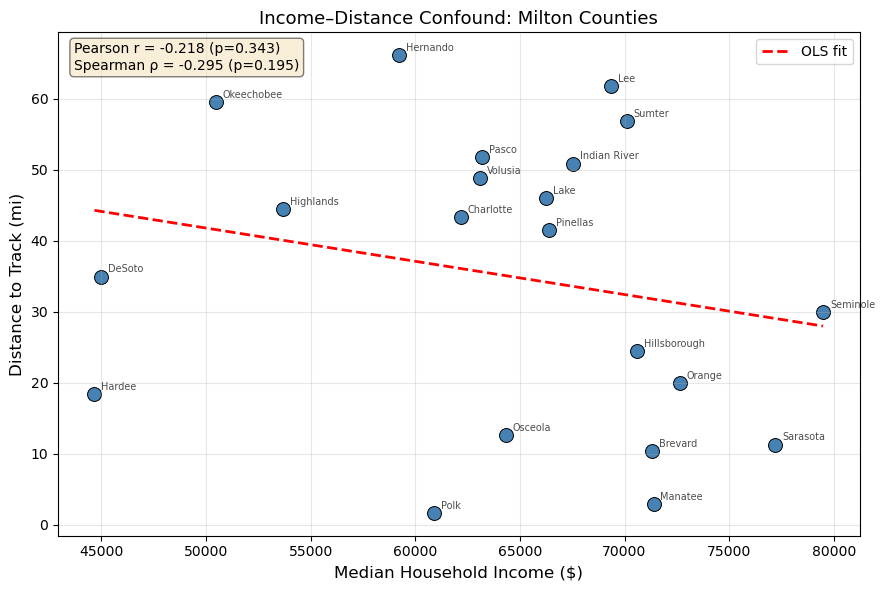


Median distance-to-track by income quartile:
income_quartile
Q1 (lowest)     39.7
Q2              46.0
Q3              50.8
Q4 (highest)    11.3
Name: dist_to_track_mi, dtype: float64


In [3]:
# ── Correlation between income and distance ──
r_p, p_p = pearsonr(df["median_household_income"], df["dist_to_track_mi"])
r_s, p_s = spearmanr(df["median_household_income"], df["dist_to_track_mi"])

print("Income vs Distance-to-Track:")
print(f"  Pearson  r = {r_p:.3f}, p = {p_p:.4f}")
print(f"  Spearman ρ = {r_s:.3f}, p = {p_s:.4f}")

# ── Scatter plot ──
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df["median_household_income"], df["dist_to_track_mi"],
           s=100, edgecolors="black", linewidth=0.7, c="steelblue")

for _, row in df.iterrows():
    ax.annotate(row["NAME"], (row["median_household_income"], row["dist_to_track_mi"]),
                fontsize=7, alpha=0.7, xytext=(5, 3), textcoords="offset points")

# Fit line
z = np.polyfit(df["median_household_income"], df["dist_to_track_mi"], 1)
x_range = np.linspace(df["median_household_income"].min(), df["median_household_income"].max(), 100)
ax.plot(x_range, np.polyval(z, x_range), color="red", ls="--", lw=2, label="OLS fit")

ax.text(0.02, 0.98, f"Pearson r = {r_p:.3f} (p={p_p:.3f})\nSpearman ρ = {r_s:.3f} (p={p_s:.3f})",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="wheat", alpha=0.5))

ax.set_xlabel("Median Household Income ($)", fontsize=12)
ax.set_ylabel("Distance to Track (mi)", fontsize=12)
ax.set_title("Income–Distance Confound: Milton Counties", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "income_vs_distance.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Median distance per quartile ──
print("\nMedian distance-to-track by income quartile:")
print(df.groupby("income_quartile")["dist_to_track_mi"].median().round(1))

## 3. Residualize DVs Against Distance

For each DV:
1. Regress DV ~ distance-to-track
2. Extract residuals: `DV_resid = DV - predicted(distance)`

The residual represents: "How much did this county deviate from what we'd expect
given its distance to the track?" Positive residual = worse than expected for its distance.

In [4]:
DV_CONFIGS = {
    "largest_drop": {
        "col": "largest_drop",
        "label": "Largest Drop — Within (%)",
        "resid_label": "Largest Drop residual (distance-adjusted)",
    },
    "recovery_days": {
        "col": "recovery_days",
        "label": "Recovery Time — Within (days)",
        "resid_label": "Recovery Time residual (distance-adjusted)",
    },
    "largest_increase": {
        "col": "largest_increase",
        "label": "Outflow Increase (%)",
        "resid_label": "Outflow Increase residual (distance-adjusted)",
    },
    "total_disruption": {
        "col": "total_disruption",
        "label": "Total Disruption (days × %)",
        "resid_label": "Total Disruption residual (distance-adjusted)",
    },
}

quartile_labels = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]

In [5]:
# ── Residualize each DV against distance ──
distance_models = {}

for dv_key, cfg in DV_CONFIGS.items():
    dv_col = cfg["col"]
    valid = df[[dv_col, "dist_to_track_mi"]].dropna()

    X = sm.add_constant(valid["dist_to_track_mi"])
    y = valid[dv_col]
    model = sm.OLS(y, X).fit()

    resid_col = f"{dv_col}_resid"
    df[resid_col] = np.nan
    df.loc[valid.index, resid_col] = model.resid.values

    distance_models[dv_key] = model

    print(f"{cfg['label']}:")
    print(f"  DV ~ distance: R² = {model.rsquared:.4f}, distance coef = {model.params.iloc[1]:.4f}, p = {model.pvalues.iloc[1]:.4f}")
    print(f"  Residual col: {resid_col}")
    print()

Largest Drop — Within (%):
  DV ~ distance: R² = 0.0542, distance coef = -0.0746, p = 0.3097
  Residual col: largest_drop_resid

Recovery Time — Within (days):
  DV ~ distance: R² = 0.0001, distance coef = -0.0002, p = 0.9752
  Residual col: recovery_days_resid

Outflow Increase (%):
  DV ~ distance: R² = 0.0135, distance coef = -0.2936, p = 0.6162
  Residual col: largest_increase_resid

Total Disruption (days × %):
  DV ~ distance: R² = 0.0444, distance coef = 0.3558, p = 0.3594
  Residual col: total_disruption_resid



## 4. Partial Correlations: Income–DV Controlling for Distance

In [6]:
def partial_corr_pearson(x, y, z):
    """Partial Pearson correlation of x and y controlling for z."""
    r_xy, _ = pearsonr(x, y)
    r_xz, _ = pearsonr(x, z)
    r_yz, _ = pearsonr(y, z)
    numer = r_xy - r_xz * r_yz
    denom = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    if denom < 1e-12:
        return np.nan, np.nan
    r_partial = numer / denom
    # t-test for significance (df = n-3 for partial corr with 1 control)
    n = len(x)
    t_stat = r_partial * np.sqrt((n - 3) / (1 - r_partial**2 + 1e-12))
    from scipy.stats import t as t_dist
    p_val = 2 * (1 - t_dist.cdf(abs(t_stat), df=n-3))
    return r_partial, p_val


print("="*70)
print("PARTIAL CORRELATIONS: Income–DV | Distance")
print("="*70)
print(f"{'DV':<35} {'Raw r':>8} {'Raw p':>8} {'Partial r':>10} {'Partial p':>10}")
print("-"*71)

partial_rows = []

for dv_key, cfg in DV_CONFIGS.items():
    dv_col = cfg["col"]
    valid = df[[dv_col, "median_household_income", "dist_to_track_mi"]].dropna()

    # Raw correlation
    r_raw, p_raw = pearsonr(valid["median_household_income"], valid[dv_col])

    # Partial correlation
    r_part, p_part = partial_corr_pearson(
        valid["median_household_income"].values,
        valid[dv_col].values,
        valid["dist_to_track_mi"].values
    )

    sig_raw = "**" if p_raw < 0.05 else "*" if p_raw < 0.1 else ""
    sig_part = "**" if p_part < 0.05 else "*" if p_part < 0.1 else ""

    print(f"{cfg['label']:<35} {r_raw:>8.3f} {p_raw:>8.3f} {r_part:>10.3f} {p_part:>10.3f}  {sig_part}")

    partial_rows.append({
        "DV": cfg["label"],
        "raw_r": round(r_raw, 4),
        "raw_p": round(p_raw, 4),
        "partial_r": round(r_part, 4),
        "partial_p": round(p_part, 4),
    })

partial_df = pd.DataFrame(partial_rows)
partial_df.to_csv(os.path.join(OUTPUT_DIR, "partial_correlations.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/partial_correlations.csv")

PARTIAL CORRELATIONS: Income–DV | Distance
DV                                     Raw r    Raw p  Partial r  Partial p
-----------------------------------------------------------------------
Largest Drop — Within (%)              0.074    0.751      0.024      0.919  
Recovery Time — Within (days)         -0.038    0.871     -0.040      0.866  
Outflow Increase (%)                   0.272    0.232      0.255      0.278  
Total Disruption (days × %)           -0.087    0.709     -0.043      0.858  

Saved to ../results/confound_analysis_milton//partial_correlations.csv


## 5. Kruskal-Wallis on Distance-Residualized DVs

Repeat the quartile analysis, but now using the distance-adjusted residuals.
This answers: "After removing the effect of distance, do income quartiles differ?"

In [7]:
def run_kw_on_residuals(df, resid_col, dv_label, quartile_col, quartile_labels):
    """Kruskal-Wallis + Mann-Whitney on residualized DV."""
    groups = [df[df[quartile_col] == q][resid_col].dropna().values for q in quartile_labels]

    stat, p_kw = kruskal(*groups)

    print(f"\n{'─'*60}")
    print(f"{dv_label} (distance-adjusted)")
    print(f"{'─'*60}")
    print(f"  Group medians (residual):")
    for q, g in zip(quartile_labels, groups):
        print(f"    {q}: median = {np.median(g):+.2f}, n = {len(g)}")

    sig = "**" if p_kw < 0.05 else "*" if p_kw < 0.1 else "n.s."
    print(f"  Kruskal-Wallis H = {stat:.4f}, p = {p_kw:.4f} {sig}")

    # Q1 vs Q4
    q1, q4 = groups[0], groups[3]
    if len(q1) >= 2 and len(q4) >= 2:
        u, p_mw = mannwhitneyu(q1, q4, alternative="two-sided")
        sig_mw = "**" if p_mw < 0.05 else "*" if p_mw < 0.1 else "n.s."
        print(f"  Mann-Whitney Q1 vs Q4: U = {u:.1f}, p = {p_mw:.4f} {sig_mw}")
    else:
        p_mw = None

    # Spearman: income vs residual
    valid = df[[resid_col, "median_household_income"]].dropna()
    rho, p_sp = spearmanr(valid["median_household_income"], valid[resid_col])
    sig_sp = "**" if p_sp < 0.05 else "*" if p_sp < 0.1 else "n.s."
    print(f"  Spearman (income vs residual): ρ = {rho:.3f}, p = {p_sp:.4f} {sig_sp}")

    return {
        "dv": dv_label,
        "KW_H": round(stat, 4),
        "KW_p": round(p_kw, 4),
        "MW_Q1vQ4_p": round(p_mw, 4) if p_mw is not None else None,
        "Spearman_rho": round(rho, 4),
        "Spearman_p": round(p_sp, 4),
        "median_Q1": round(np.median(groups[0]), 2),
        "median_Q4": round(np.median(groups[3]), 2),
    }

In [8]:
resid_results = []

for dv_key, cfg in DV_CONFIGS.items():
    resid_col = f"{cfg['col']}_resid"
    res = run_kw_on_residuals(df, resid_col, cfg["label"],
                              "income_quartile", quartile_labels)
    resid_results.append(res)

resid_df = pd.DataFrame(resid_results)
print("\n\n" + "="*70)
print("SUMMARY: Kruskal-Wallis on Distance-Residualized DVs")
print("="*70)
display(resid_df)

resid_df.to_csv(os.path.join(OUTPUT_DIR, "kw_residualized_summary.csv"), index=False)
print(f"\nSaved to {OUTPUT_DIR}/kw_residualized_summary.csv")


────────────────────────────────────────────────────────────
Largest Drop — Within (%) (distance-adjusted)
────────────────────────────────────────────────────────────
  Group medians (residual):
    Q1 (lowest): median = -0.74, n = 6
    Q2: median = -7.42, n = 5
    Q3: median = -1.40, n = 5
    Q4 (highest): median = +1.31, n = 5
  Kruskal-Wallis H = 1.3429, p = 0.7190 n.s.
  Mann-Whitney Q1 vs Q4: U = 13.0, p = 0.7922 n.s.
  Spearman (income vs residual): ρ = 0.068, p = 0.7712 n.s.

────────────────────────────────────────────────────────────
Recovery Time — Within (days) (distance-adjusted)
────────────────────────────────────────────────────────────
  Group medians (residual):
    Q1 (lowest): median = -0.07, n = 6
    Q2: median = -0.03, n = 5
    Q3: median = -0.10, n = 5
    Q4 (highest): median = -0.07, n = 5
  Kruskal-Wallis H = 0.4390, p = 0.9321 n.s.
  Mann-Whitney Q1 vs Q4: U = 14.0, p = 0.9307 n.s.
  Spearman (income vs residual): ρ = 0.040, p = 0.8624 n.s.

───────────

,dv,KW_H,KW_p,MW_Q1vQ4_p,Spearman_rho,Spearman_p,median_Q1,median_Q4
0,Largest Drop — Within (%),1.3429,0.7190,0.7922,0.0675,0.7712,-0.74,1.31
1,Recovery Time — Within (days),0.4390,0.9321,0.9307,0.0403,0.8624,-0.07,-0.07
2,Outflow Increase (%),2.9091,0.4059,0.9307,0.1195,0.6060,-35.39,-41.85
3,Total Disruption (days × %),0.5922,0.8982,0.6623,-0.1273,0.5825,6.37,-8.31



Saved to ../results/confound_analysis_milton//kw_residualized_summary.csv


## 6. Boxplots: Raw vs Distance-Adjusted (Side by Side)

For each DV, show the raw quartile boxplot next to the distance-adjusted boxplot.

Saved: ../results/confound_analysis_milton/figures/raw_vs_adjusted_largest_drop.png


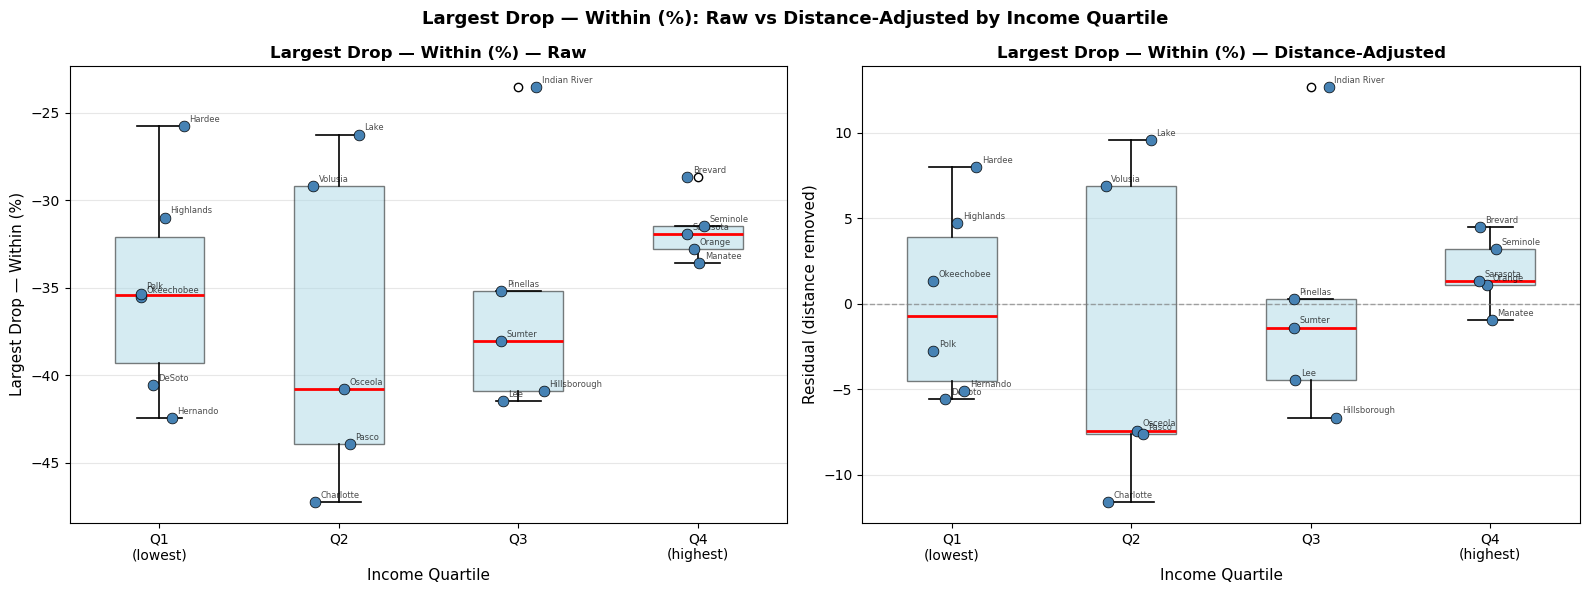

Saved: ../results/confound_analysis_milton/figures/raw_vs_adjusted_recovery_days.png


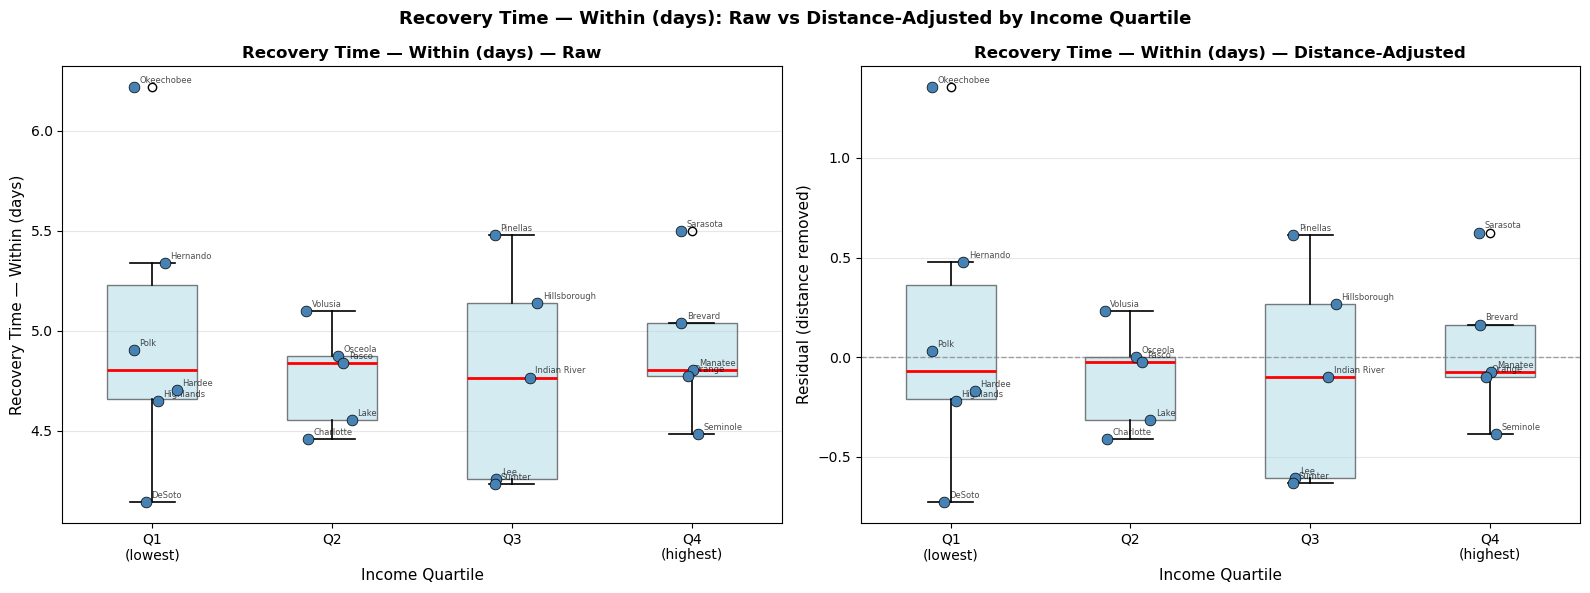

Saved: ../results/confound_analysis_milton/figures/raw_vs_adjusted_largest_increase.png


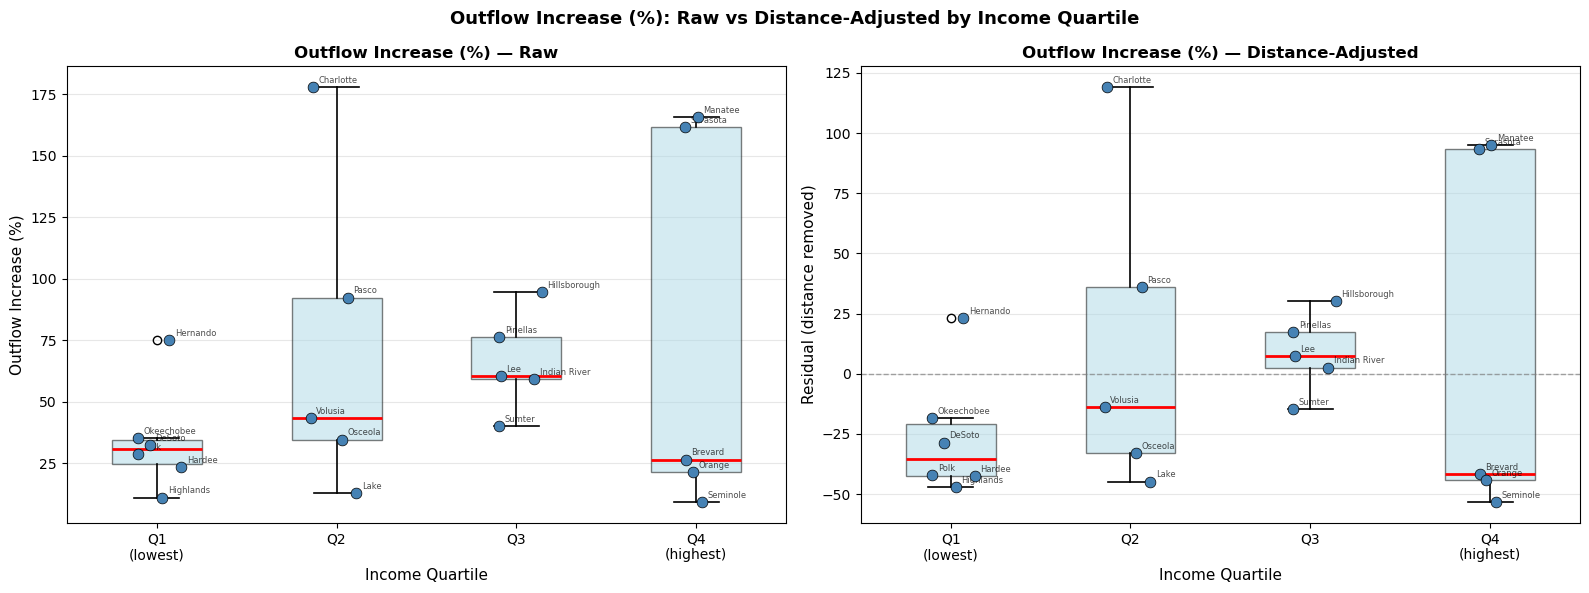

Saved: ../results/confound_analysis_milton/figures/raw_vs_adjusted_total_disruption.png


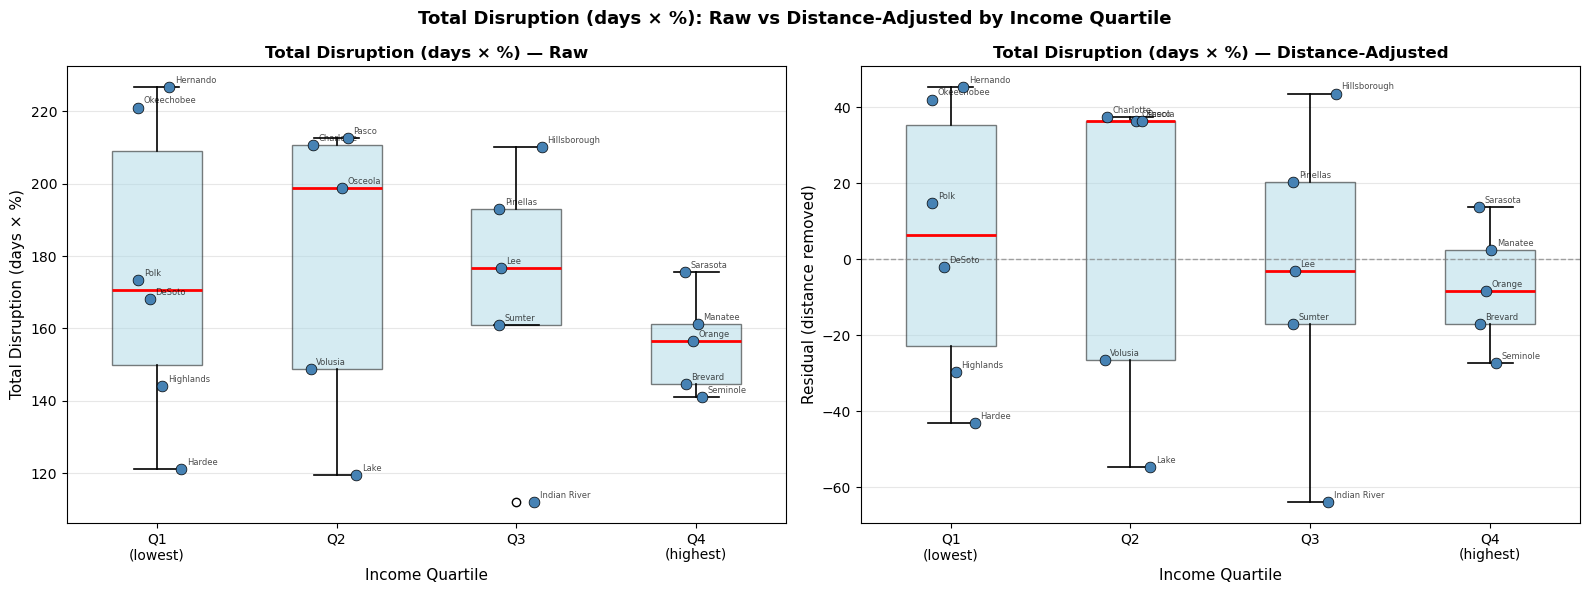

In [9]:
for dv_key, cfg in DV_CONFIGS.items():
    dv_col = cfg["col"]
    resid_col = f"{dv_col}_resid"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for ax, col, title_suffix in [
        (ax1, dv_col, "Raw"),
        (ax2, resid_col, "Distance-Adjusted")
    ]:
        box_data = [df[df["income_quartile"] == q][col].dropna().values
                    for q in quartile_labels]

        bp = ax.boxplot(box_data, positions=range(4), widths=0.5,
                        patch_artist=True,
                        boxprops=dict(facecolor="lightblue", alpha=0.5),
                        medianprops=dict(color="red", linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2))

        # Overlay points with county names
        np.random.seed(42)
        for i, q in enumerate(quartile_labels):
            subset = df[df["income_quartile"] == q].dropna(subset=[col])
            jitter = np.random.uniform(-0.15, 0.15, size=len(subset))
            ax.scatter(np.full(len(subset), i) + jitter, subset[col],
                       s=60, edgecolors="black", linewidth=0.5,
                       c="steelblue", zorder=5)
            for idx_j, (_, row) in enumerate(subset.iterrows()):
                ax.annotate(row["NAME"],
                            (i + jitter[idx_j], row[col]),
                            fontsize=6, alpha=0.7,
                            xytext=(4, 3), textcoords="offset points")

        ax.set_xticks(range(4))
        ax.set_xticklabels(["Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)"], fontsize=10)
        ax.set_xlabel("Income Quartile", fontsize=11)
        ax.set_title(f"{cfg['label']} — {title_suffix}", fontsize=12, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

        if title_suffix == "Distance-Adjusted":
            ax.axhline(0, color="gray", ls="--", lw=1, alpha=0.7)
            ax.set_ylabel("Residual (distance removed)", fontsize=11)
        else:
            ax.set_ylabel(cfg["label"], fontsize=11)

    fig.suptitle(f"{cfg['label']}: Raw vs Distance-Adjusted by Income Quartile",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "figures", f"raw_vs_adjusted_{dv_key}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

## 7. Comparison Table: Raw vs Distance-Adjusted Results

In [10]:
# Load raw results from quartile notebook
raw_kw_path = "../results/quartile_analysis_milton/kruskal_wallis_summary.csv"
if os.path.exists(raw_kw_path):
    raw_kw = pd.read_csv(raw_kw_path)
else:
    raw_kw = None
    print("Raw KW results not found — run quartile_analysis_milton.ipynb first")

if raw_kw is not None:
    print("="*80)
    print("COMPARISON: Raw vs Distance-Adjusted")
    print("="*80)

    compare_rows = []
    for i, (dv_key, cfg) in enumerate(DV_CONFIGS.items()):
        raw_row = raw_kw.iloc[i]
        adj_row = resid_results[i]
        compare_rows.append({
            "DV": cfg["label"],
            "Raw KW p": raw_row["KW_p"],
            "Adj KW p": adj_row["KW_p"],
            "Raw MW Q1vQ4 p": raw_row.get("MW_Q1vQ4_p"),
            "Adj MW Q1vQ4 p": adj_row.get("MW_Q1vQ4_p"),
            "Raw Spearman ρ": raw_row.get("Spearman_rho"),
            "Adj Spearman ρ": adj_row["Spearman_rho"],
            "Raw Spearman p": raw_row.get("Spearman_p"),
            "Adj Spearman p": adj_row["Spearman_p"],
        })

    compare_df = pd.DataFrame(compare_rows)
    display(compare_df)

    compare_df.to_csv(os.path.join(OUTPUT_DIR, "raw_vs_adjusted_comparison.csv"), index=False)
    print(f"\nSaved to {OUTPUT_DIR}/raw_vs_adjusted_comparison.csv")

COMPARISON: Raw vs Distance-Adjusted


,DV,Raw KW p,Adj KW p,Raw MW Q1vQ4 p,Adj MW Q1vQ4 p,Raw Spearman ρ,Adj Spearman ρ,Raw Spearman p,Adj Spearman p
0,Largest Drop — Within (%),0.5296,0.7190,0.3290,0.7922,0.1481,0.0675,0.5219,0.7712
1,Recovery Time — Within (days),0.9321,0.9321,0.9307,0.9307,0.0403,0.0403,0.8624,0.8624
2,Outflow Increase (%),0.3275,0.4059,1.0000,0.9307,0.1338,0.1195,0.5632,0.6060
3,Total Disruption (days × %),0.6976,0.8982,0.5368,0.6623,-0.1948,-0.1273,0.3974,0.5825



Saved to ../results/confound_analysis_milton//raw_vs_adjusted_comparison.csv


## 8. Interpretation

**Reading the comparison table:**

| Scenario | What it means |
|---|---|
| Raw p > 0.05, Adjusted p > 0.05 | No income effect, even after removing distance confound |
| Raw p > 0.05, Adjusted p < 0.05 | **Hidden income effect** — distance was masking it (suppression) |
| Raw p < 0.05, Adjusted p > 0.05 | The apparent income effect was actually driven by distance |
| Raw p < 0.05, Adjusted p < 0.05 | Income effect is real and independent of distance |

**Partial correlation interpretation:**
- If |partial r| > |raw r| → distance was a **suppressor** (concealing the income effect)
- If |partial r| < |raw r| → distance was a **confound** (inflating the income effect)
- If partial r changes sign → the raw association was spurious